# Détection d'intrusion NSL-KDD — RNN-IDS (Yin, Zhu, Fei & He, 2017)

Architecture suivie fidèlement : **"A Deep Learning Approach for Intrusion Detection Using Recurrent Neural Networks"**, IEEE Access, 2017 (RNN-IDS).

**Ce que fait le papier, reproduit ici :**
- Un **RNN classique** (SimpleRNN, sans mémoire de type LSTM/GRU)
- **1 couche cachée de 80 neurones** (meilleure configuration trouvée par les auteurs en testant 20 à 240 neurones)
- **Taux d'apprentissage = 0.1**, optimiseur **SGD** (les auteurs étudient l'impact du learning rate entre 0.01 et 0.5 ; ~0.1 donne les meilleurs résultats stables)
- **Couche de sortie softmax**
- **41 features mappées vers 122** après one-hot encoding + normalisation → exactement notre pipeline de prétraitement, aucun changement nécessaire
- Classification **multi-classe** (Normal/Dos/R2L/U2R/Probe), comme demandé
- Chaque échantillon est traité comme une séquence à **1 seul pas de temps** (les données NSL-KDD ne sont pas intrinsèquement séquentielles ; c'est ce que font Yin et al. pour pouvoir utiliser un RNN sur ce type de données tabulaires)

**Résultats rapportés dans le papier (à titre de comparaison) :** ACC ≈ 83.28% / 81.29%, avec des taux de détection (DR) et faux positifs (FPR) par classe nettement plus faibles sur R2L et U2R — c'est un résultat connu et attendu de cette architecture, pas un bug.

**Étape 1 :** sur Colab, uploade `KDDTrain+.txt` et `KDDTest+.txt` (icône dossier à gauche), puis exécute les cellules dans l'ordre.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                              precision_score, f1_score, classification_report)

import tensorflow as tf
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version :", tf.__version__)
%matplotlib inline

TensorFlow version : 2.20.0


## 1. Chargement des données (fichiers uploadés manuellement)

In [ ]:
# Optionnel : décommente pour uploader directement depuis cette cellule
# from google.colab import files
# uploaded = files.upload()

training_set_path = "KDDTrain+.txt"
test_set_path = "KDDTest+.txt"

training_df = pd.read_csv(training_set_path, header=None)
testing_df = pd.read_csv(test_set_path, header=None)

print("Training set :", training_df.shape)
print("Testing set  :", testing_df.shape)

Training set : (125973, 43)
Testing set  : (22544, 43)


In [ ]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'outcome','difficulty'
]
training_df.columns = columns
testing_df.columns = columns
training_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Étiquetage en 5 classes

In [ ]:
dos_attacks=["snmpgetattack","back","land","neptune","smurf","teardrop","pod","apache2","udpstorm","processtable","mailbomb"]
r2l_attacks=["snmpguess","worm","httptunnel","named","xlock","xsnoop","sendmail","ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster"]
u2r_attacks=["sqlattack","buffer_overflow","loadmodule","perl","rootkit","xterm","ps"]
probe_attacks=["ipsweep","nmap","portsweep","satan","saint","mscan"]
classes=["Normal","Dos","R2L","U2R","Probe"]

def label_attack(row):
    if row["outcome"] in dos_attacks: return classes[1]
    if row["outcome"] in r2l_attacks: return classes[2]
    if row["outcome"] in u2r_attacks: return classes[3]
    if row["outcome"] in probe_attacks: return classes[4]
    return classes[0]

if "Class" not in training_df.columns:
    test_samples_length = len(testing_df)
    df = pd.concat([training_df, testing_df])
    df["Class"] = df.apply(label_attack, axis=1)
    df = df.drop("outcome", axis=1)
    df = df.drop("difficulty", axis=1)

    training_df = df.iloc[:-test_samples_length, :].copy()
    testing_df = df.iloc[-test_samples_length:, :].copy()
else:
    print("Déjà étiqueté (colonne 'Class' présente) — cellule ignorée pour éviter un double passage.")

print(training_df["Class"].value_counts())
print()
print(testing_df["Class"].value_counts())

Class
Normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Class
Normal    9711
Dos       7636
R2L       2709
Probe     2421
U2R         67
Name: count, dtype: int64


## 3. Prétraitement : one-hot encoding + normalisation (41 → 122 features, comme dans le papier)

In [ ]:
def minmax_scale_values(training_df, testing_df, col_name):
    scaler = MinMaxScaler()
    scaler = scaler.fit(training_df[col_name].values.reshape(-1, 1))
    training_df[col_name] = scaler.transform(training_df[col_name].values.reshape(-1, 1))
    testing_df[col_name] = scaler.transform(testing_df[col_name].values.reshape(-1, 1))

def encode_text(training_df, testing_df, name):
    training_set_dummies = pd.get_dummies(training_df[name])
    testing_set_dummies = pd.get_dummies(testing_df[name])
    for x in training_set_dummies.columns:
        dummy_name = "{}_{}".format(name, x)
        training_df[dummy_name] = training_set_dummies[x]
        if x in testing_set_dummies.columns:
            testing_df[dummy_name] = testing_set_dummies[x]
        else:
            testing_df[dummy_name] = np.zeros(len(testing_df))
    training_df.drop(name, axis=1, inplace=True)
    testing_df.drop(name, axis=1, inplace=True)

symbolic_columns = ["protocol_type", "service", "flag"]
label_column = "Class"
for column in df.columns:
    if column in symbolic_columns:
        encode_text(training_df, testing_df, column)
    elif column != label_column:
        minmax_scale_values(training_df, testing_df, column)

print("Nombre de features après encodage :", training_df.shape[1] - 1, "(le papier obtient 122)")
training_df.head()

Nombre de features après encodage : 122 (le papier obtient 122)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X_train = training_df.drop("Class", axis=1).values.astype("float32")
y_train_labels = training_df["Class"].values
X_test = testing_df.drop("Class", axis=1).values.astype("float32")
y_test_labels = testing_df["Class"].values

class_to_idx = {c: i for i, c in enumerate(classes)}
y_train_idx = np.array([class_to_idx[c] for c in y_train_labels])
y_test_idx = np.array([class_to_idx[c] for c in y_test_labels])

y_train = to_categorical(y_train_idx, num_classes=len(classes))
y_test = to_categorical(y_test_idx, num_classes=len(classes))

# Le RNN attend une séquence : on traite chaque échantillon comme 1 pas de temps de 122 features
X_train_seq = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_seq = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("X_train_seq :", X_train_seq.shape, " y_train :", y_train.shape)
print("X_test_seq  :", X_test_seq.shape,  " y_test  :", y_test.shape)

X_train_seq : (125973, 1, 122)  y_train : (125973, 5)
X_test_seq  : (22544, 1, 122)  y_test  : (22544, 5)


## 4. Modèle RNN-IDS (Yin et al., 2017)

Architecture exacte du papier : Input → SimpleRNN(80, tanh) → Dense(5, softmax), optimiseur SGD, learning rate 0.1.

In [ ]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

input_dim = X_train.shape[1]
hidden_nodes = 80

inp = Input(shape=(1, input_dim))
rnn = SimpleRNN(hidden_nodes, activation='tanh', name='rnn_hidden')(inp)
drop = Dropout(0.3)(rnn)
out = Dense(len(classes), activation='softmax', name='softmax_output')(drop)

rnn_model = Model(inp, out, name='RNN_IDS_Yin2017')
rnn_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
rnn_model.summary()

Model: "RNN_IDS_Yin2017"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 122)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_hidden (SimpleRNN)          │ (None, 80)             │        16,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 5)              │           405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,645 (65.02 KB)

 Trainable params: 16,645 (65.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

history = rnn_model.fit(
    X_train_seq, y_train,
    epochs=100,
    batch_size=100,
    shuffle=True,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8896 - loss: 0.4712 - val_accuracy: 0.9169 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 2/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9227 - loss: 0.2535 - val_accuracy: 0.9170 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 3/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9293 - loss: 0.2268 - val_accuracy: 0.9288 - val_loss: 0.1946 - learning_rate: 0.0010
Epoch 4/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9342 - loss: 0.2145 - val_accuracy: 0.9368 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 5/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9383 - loss: 0.2106 - val_accuracy: 0.9330 - val_loss: 0.1836 - learning_rate: 0.0010
Epoch 6/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9386 - loss: 0.1995 - val_accuracy: 0.9473 - val_loss: 0.1428 - learning_rate: 0.0010
Epoch 7/100
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9

## 5. Évaluation sur le jeu de test (ACC, DR, FPR par classe — format du tableau de référence)

In [ ]:
y_pred_probs = rnn_model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_idx

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("Accuracy globale : {:.4f}".format(accuracy))
print("Precision (macro) : {:.4f}".format(precision_macro))
print("Recall (macro)    : {:.4f}".format(recall_macro))
print("F1 (macro)        : {:.4f}\n".format(f1_macro))

print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy globale : 0.7675
Precision (macro) : 0.6422
Recall (macro)    : 0.6364
F1 (macro)        : 0.5642

              precision    recall  f1-score   support

      Normal       0.71      0.92      0.80      9711
         Dos       0.91      0.81      0.86      7636
         R2L       0.68      0.15      0.25      2709
         U2R       0.08      0.58      0.15        67
       Probe       0.82      0.72      0.77      2421

    accuracy                           0.77     22544
   macro avg       0.64      0.64      0.56     22544
weighted avg       0.79      0.77      0.75     22544



In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_idx),
    y=y_train_idx
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print(class_weight_dict)

{0: np.float64(0.3741235169208381), 1: np.float64(0.5485792670977856), 2: np.float64(25.321206030150755), 3: np.float64(484.51153846153846), 4: np.float64(2.1615133836650653)}


In [ ]:
# ACC, DR (recall) et FPR par classe (one-vs-rest), comme les colonnes du tableau Yin et al.
n = len(y_true)
print(f"{'Classe':8s}  {'ACC':>8s}  {'DR':>8s}  {'FPR':>8s}")
for i, class_ in enumerate(classes):
    is_class = (y_true == i)
    pred_class = (y_pred == i)

    tp = np.sum(is_class & pred_class)
    fn = np.sum(is_class & ~pred_class)
    fp = np.sum(~is_class & pred_class)
    tn = np.sum(~is_class & ~pred_class)

    acc_c = (tp + tn) / n
    dr = tp / (tp + fn) if (tp + fn) > 0 else float('nan')   # = recall / taux de détection
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

    print(f"{class_:8s}  {acc_c:8.4f}  {dr:8.4f}  {fpr:8.4f}")

Classe         ACC        DR       FPR
Normal      0.8025    0.9192    0.2857
Dos         0.9100    0.8102    0.0388
R2L         0.8895    0.1517    0.0097
U2R         0.9798    0.5821    0.0190
Probe       0.9532    0.7187    0.0186


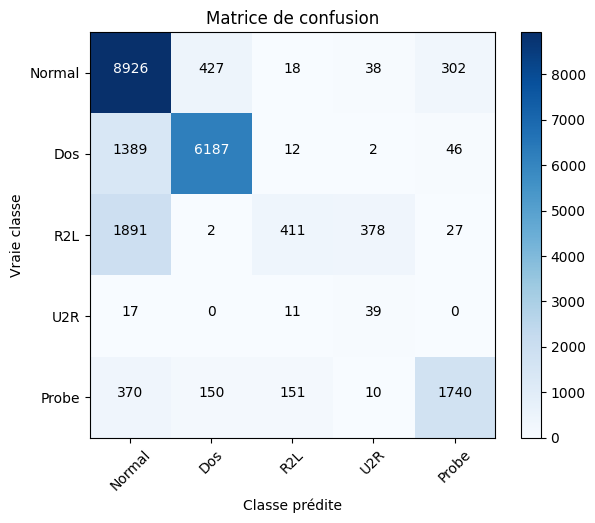

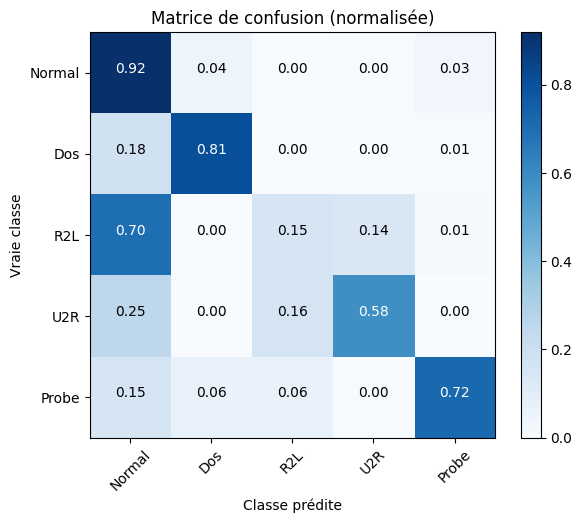

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Matrice de confusion', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 5))
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, classes)
plot_confusion_matrix(cm, classes, normalize=True, title='Matrice de confusion (normalisée)')

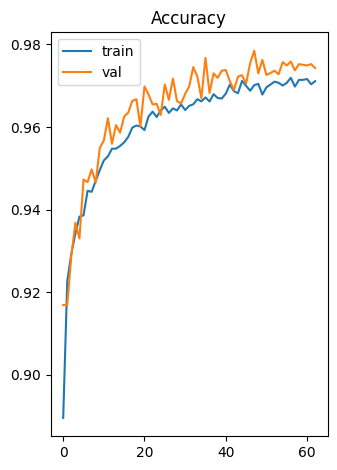

In [ ]:
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

Ce notebook reproduit fidèlement **RNN-IDS (Yin et al., 2017)** : un RNN simple (1 couche, 80 neurones) + softmax, entraîné avec SGD (lr=0.1) sur 122 features.

**Chiffres du papier pour comparaison (NSL-KDD, multi-classe) :** ACC ≈ 83.28% / 81.29%, avec un DR nettement plus faible sur R2L et U2R que sur Dos/Probe — c'est **le résultat attendu de cette architecture**, pas une erreur : les auteurs eux-mêmes rapportent ces limites dues au déséquilibre des classes et à l'absence de mémoire dans un RNN simple.

**Pistes pour ton rapport :**
- Reproduire l'étude des auteurs sur le nombre de neurones cachés (20, 40, 80, 120, 240) et le learning rate (0.01, 0.1, 0.5) pour voir l'effet sur l'accuracy — c'est justement le cœur de leur contribution
- Comparer avec `KDDTest-21.txt` (sous-ensemble plus difficile) si tu veux confronter aux chiffres complets du papier
- Comparer ce RNN simple à un LSTM ou GRU (Kim et al. 2016) pour discuter de l'apport de la mémoire à long terme sur R2L/U2R